In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
df = pd.read_csv('../data/processed/weather_clean.csv')

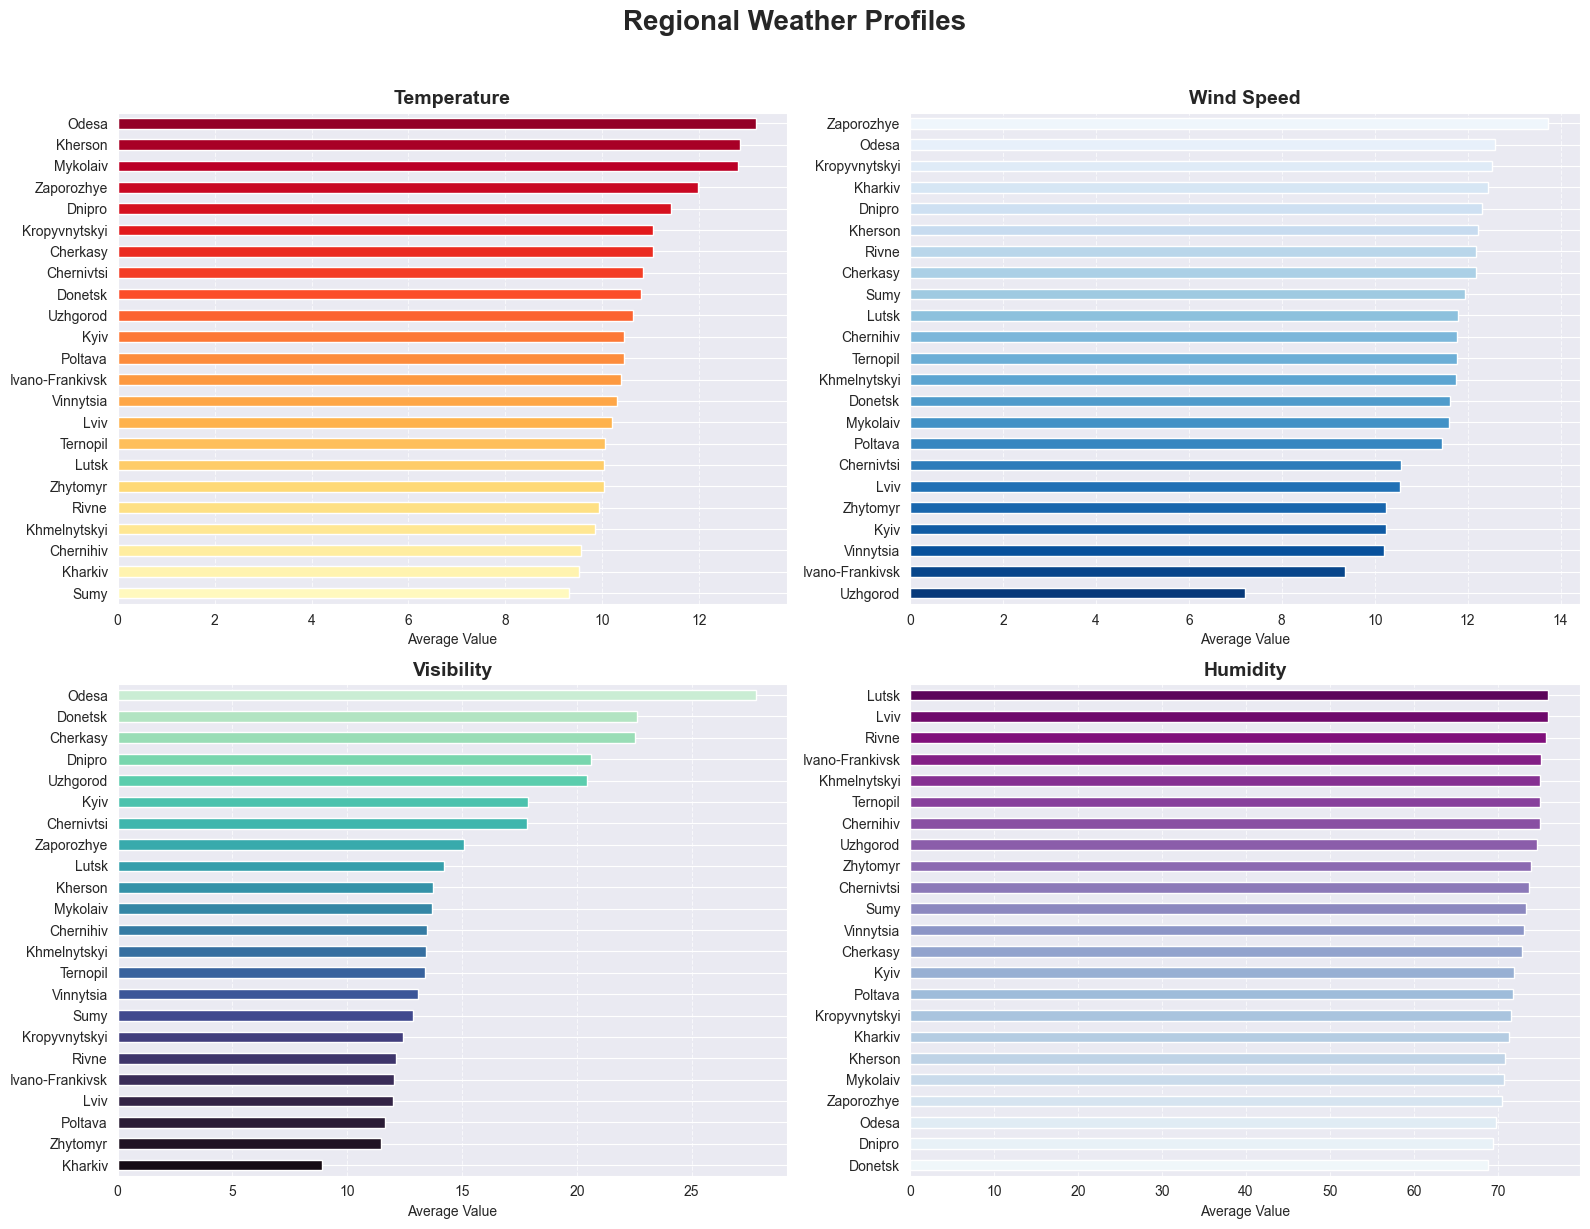

In [29]:
palettes = ["YlOrRd", "Blues_r", "mako", "BuPu"]
metrics = {'hour_temp': 'Temperature', 'hour_windspeed': 'Wind Speed', 'hour_visibility': 'Visibility', 'hour_humidity': 'Humidity'}
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, (col, title) in enumerate(metrics.items()):
    data = df.groupby('city_address')[col].mean().sort_values()
    current_palette = sns.color_palette(palettes[i], len(data))
    data.plot(kind='barh', ax=axes[i], color=current_palette)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Average Value')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)
plt.suptitle('Regional Weather Profiles', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Temperature: Southern cities Odesa, Kherson lead in heat, while the North Sumy, Kharkiv remains the coldest.
Wind Speed: Highest in Zaporizhzhia and Odesa. Uzhhorod is the calmest due to its geography.
Visibility: Odesa shows the best clarity. Kharkiv and Zhytomyr have the lowest visibility levels.
Humidity: The West Lutsk, Lviv reaches 80–90%, while the East and South stay significantly drier.

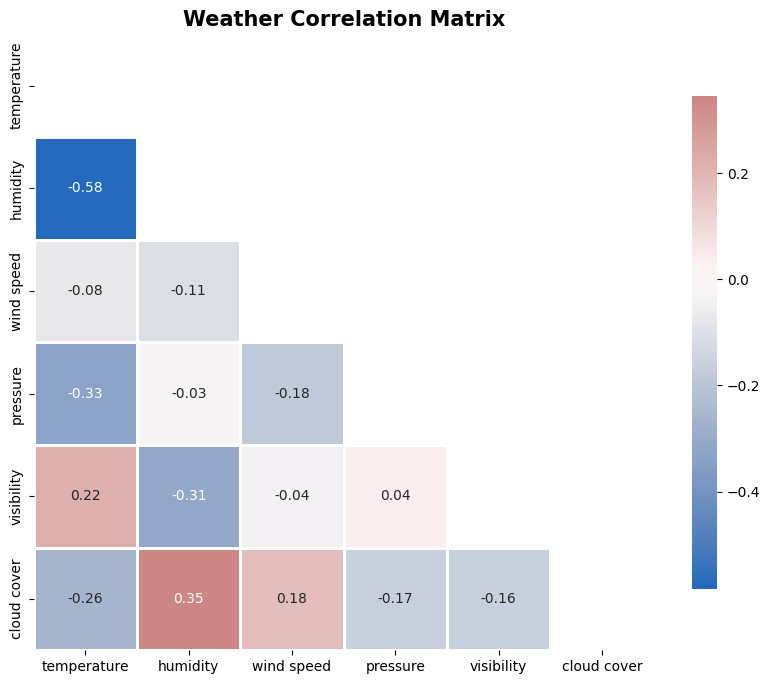

In [45]:
mapping = {'hour_temp': 'temperature', 'hour_humidity': 'humidity', 'hour_windspeed': 'wind speed',
           'hour_pressure': 'pressure', 'hour_visibility': 'visibility', 'hour_cloudcover': 'cloud cover'}
cols = ['hour_temp', 'hour_humidity', 'hour_windspeed', 'hour_pressure', 'hour_visibility', 'hour_cloudcover']
corr = df[cols].rename(columns=mapping).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='vlag', center=0, linewidths=1, linecolor='white', cbar_kws={"shrink": .8})
plt.title('Weather Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

Temperature and Humidity: Show a strong negative correlation (-0.58). As temperature rises, relative humidity typically decreases.
Cloud cover and Humidity: Positively correlated (0.35). Increased cloudiness is often associated with higher moisture levels.
Visibility and Humidity: Negative correlation (-0.31). High humidity levels tend to reduce visibility.
Temperature and Cloud cover: Slight negative correlation (-0.26), as clear days are often warmer than overcast ones.
Temperature and Visibility: Small positive correlation (0.22), warmer air can hold more moisture without condensing, often leading to clearer skies.
Wind speed, pressure, and visibility show weak or near-zero correlations

Hypothesis 1
A shorter daylight period increases electricity consumption.
A significant decrease in temperature may lead to an increase in attacks on energy infrastructure facilities. This occurs because electricity consumption rises during colder periods, which may lead to a deficit in the energy system. As a result, the energy sector becomes more vulnerable to attacks.

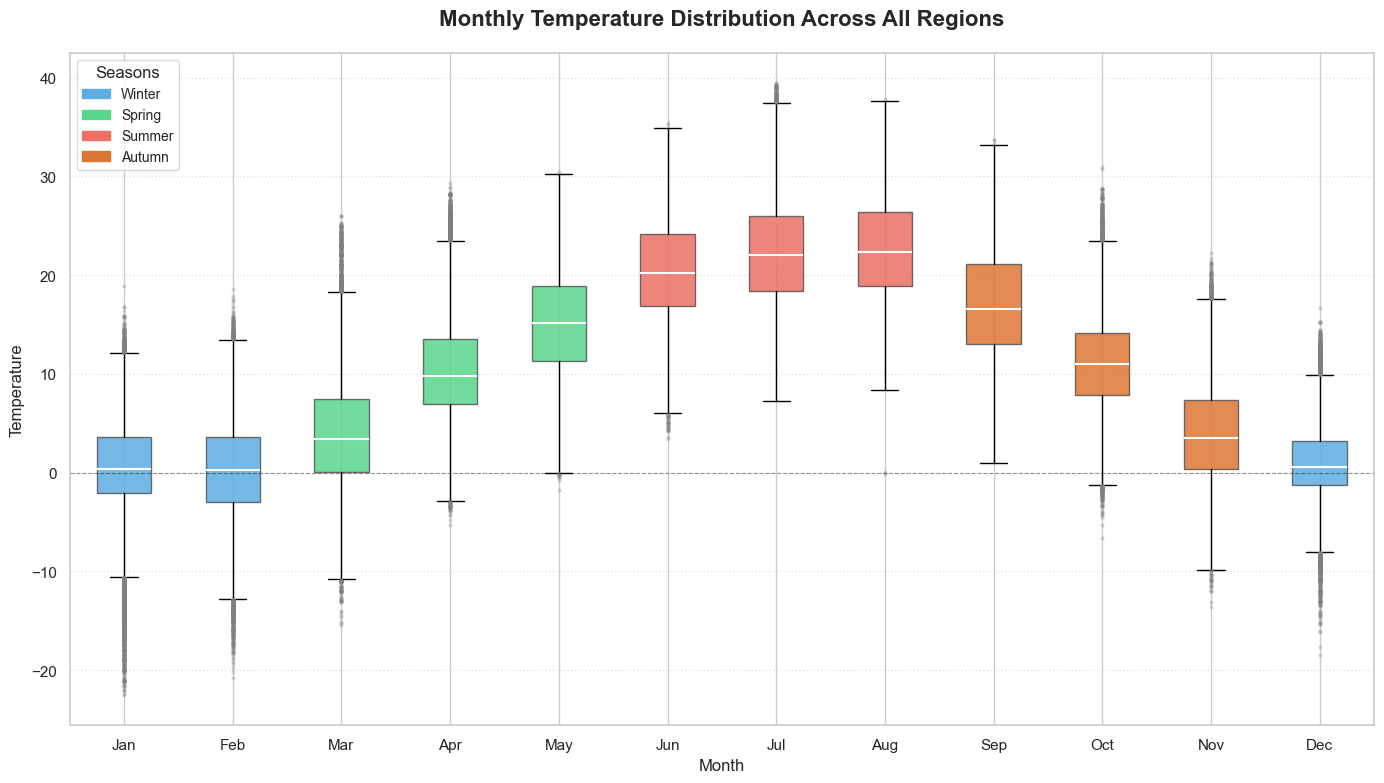

In [88]:
import matplotlib.patches as mpatches
seasons_config = {
    'Winter':  {'months': [12, 1, 2], 'color': '#5DADE2'},
    'Spring': {'months': [3, 4, 5],  'color': '#58D68D'},
    'Summer':  {'months': [6, 7, 8],  'color': '#EC7063'},
    'Autumn': {'months': [9, 10, 11], 'color': '#DC7633'}
}

month_order = list(range(1, 13))
month_names = ['Jan','Feb','Mar','Apr','May','Jun', 'Jul','Aug','Sep','Oct','Nov','Dec']
data = [df[df['month'] == m]['hour_temp'].dropna() for m in month_order]
plt.figure(figsize=(14, 8))

bp = plt.boxplot(data, patch_artist=True, medianprops=dict(color='white', linewidth=1.5),
                 flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.3, markeredgecolor='none'))

for patch, m in zip(bp['boxes'], month_order):
    for season_name, config in seasons_config.items():
        if m in config['months']:
            patch.set_facecolor(config['color'])
            patch.set_edgecolor('#555555')
            patch.set_alpha(0.85)
            break

legend_handles = [mpatches.Patch(color=cfg['color'], label=name) for name, cfg in seasons_config.items()]
plt.legend(handles=legend_handles, title="Seasons", loc='upper left', frameon=True, fontsize=10)
plt.xticks(range(1, 13), month_names)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.title('Monthly Temperature Distribution Across All Regions', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

This chart illustrates monthly temperature variations across Ukraine, highlighting seasonal trends and extremes:
Winter (December-February): Medians hover around 0 C. Wide lower whiskers and numerous outliers indicate frequent severe frosts, though most days stay between -5 C and +5 C.
Spring (March-May): A steady warming trend, with medians rising from +3 C to +15 C. Increased box height in March and May reflects high transitional variability.
Summer (June-August): Peak temperatures with medians between 22–25 C. Notable extremes range from unusual lows of +8 C to heatwaves reaching +40 C.
Autumn (September-November): Temperatures decline rapidly, with medians dropping from +16 C in September to +5 C by November.

Hypothesis 2
Low visibility may indirectly affect the duration of air raid alerts.
In winter, low visibility occurs more frequently because at low temperatures the air reaches the dew point faster, which leads to more frequent fog and precipitation. The relationship between temperature and visibility is supported by the correlation matrix graph that shows correlations between different weather parameters.

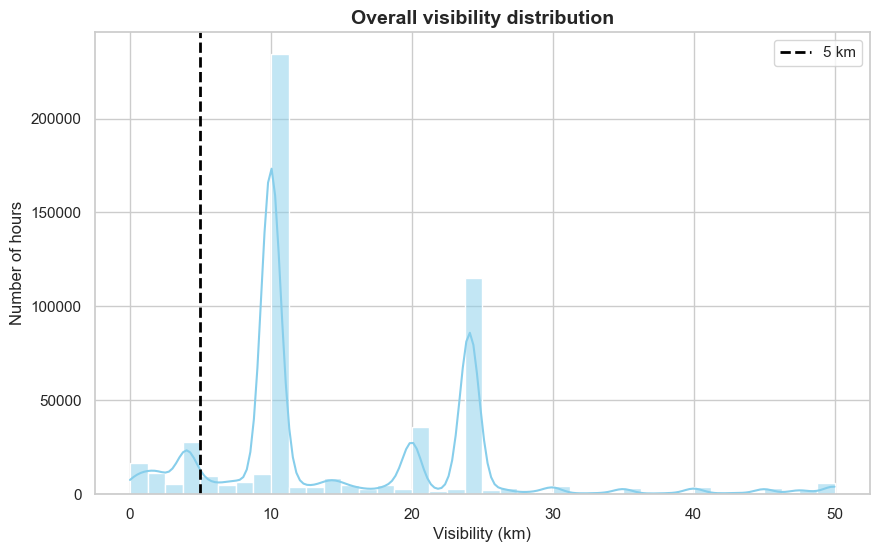

In [90]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.histplot(df['hour_visibility'], bins=40, color='skyblue', kde=True)
plt.axvline(5, color='black', linestyle='--', linewidth=2, label='5 km')
plt.title('Overall visibility distribution', fontsize=14, fontweight='bold')
plt.xlabel('Visibility (km)')
plt.ylabel('Number of hours')
plt.legend()
plt.show()

Visibility is generally high, with a primary peak at 10 km and a secondary concentration between 20–25 km. Instances of critically low visibility are rare.

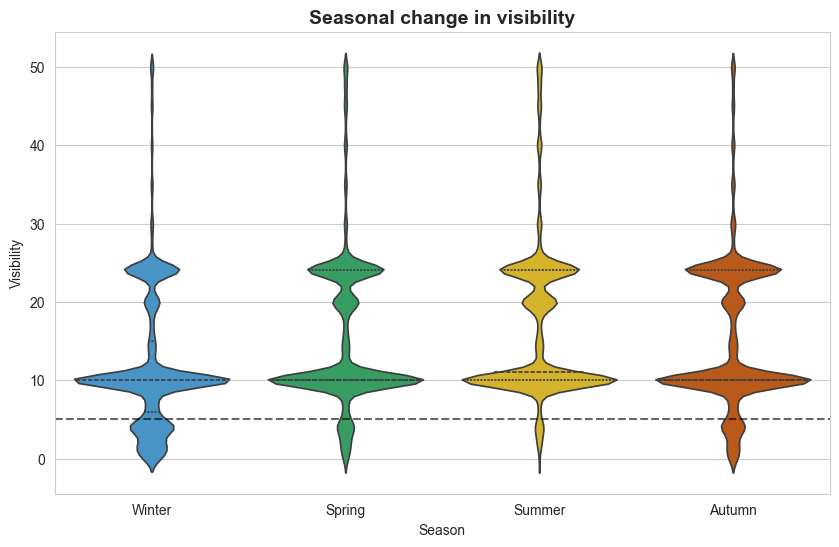

In [60]:
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df['season_name'] = df['season'].map(lambda s: season_map.get(s, s))
plt.figure(figsize=(10, 6))
palette = {'Winter': '#3498db', 'Spring': '#27ae60', 'Summer': '#f1c40f', 'Autumn': '#d35400'}
sns.violinplot(data=df, x='season_name', y='hour_visibility', hue='season_name', palette=palette, legend=False,
               order=['Winter', 'Spring', 'Summer', 'Autumn'], inner="quartile")
plt.axhline(5, color='black', linestyle='--', alpha=0.6)
plt.title('Seasonal change in visibility', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Visibility')
plt.show()

The violin plots show that visibility is most frequently concentrated around 10 km across all seasons.
Winter: Shows the most significant density in the lower range, indicating that low visibility events are most frequent during this season.
Spring and Autumn: Both show noticeable expansion at lower levels, suggesting a higher probability of poor visibility compared to summer.
Summer: Features the smallest lower tail representing the best overall visibility conditions among all seasons.

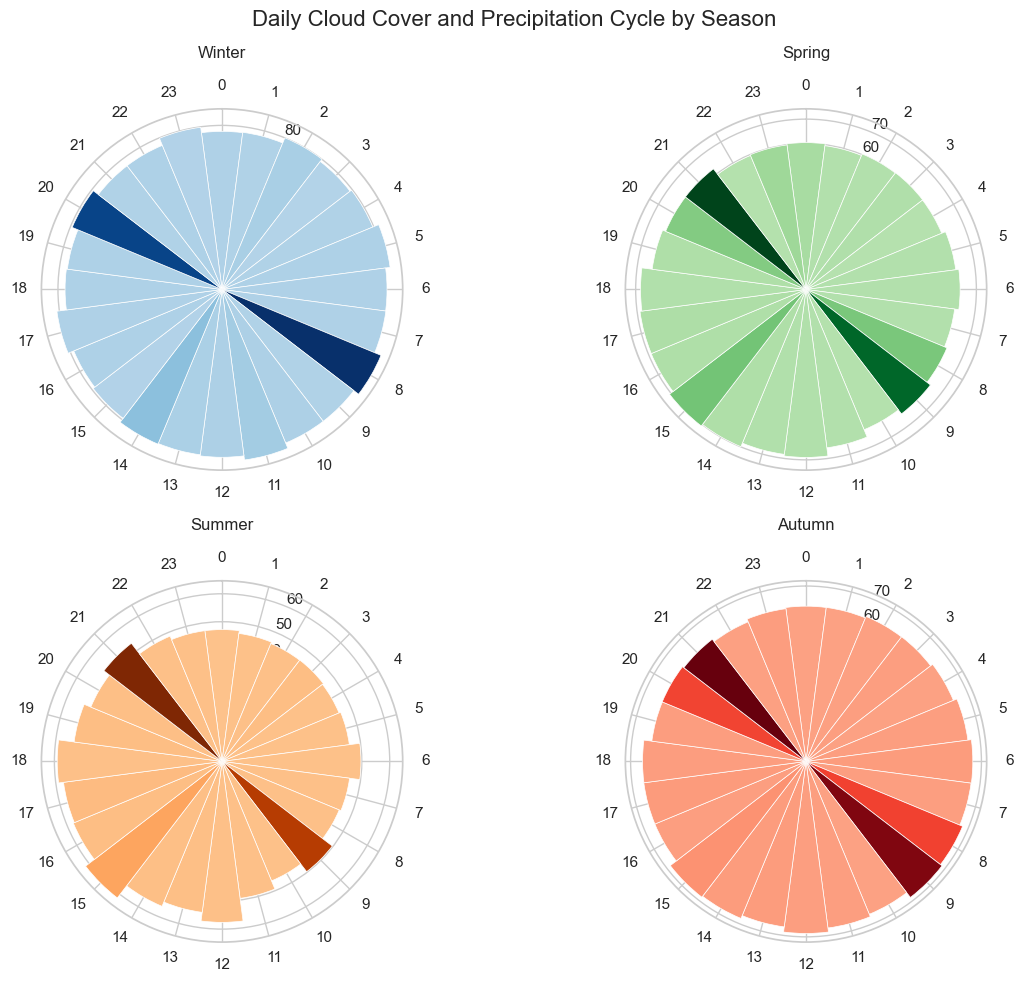

In [87]:
season_names = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
season_cmaps = {
    1: plt.get_cmap('Blues'),
    2: plt.get_cmap('Greens'),
    3: plt.get_cmap('Oranges'),
    4: plt.get_cmap('Reds')
}
fig, axes = plt.subplots(2, 2, figsize=(12,10), subplot_kw={'projection':'polar'})
axes = axes.flatten()
for i, season in enumerate([1, 2, 3, 4]):
    seasonal = df[df['season'] == season]
    hourly = seasonal.groupby('hour')[['hour_cloudcover','hour_precip']].mean().reset_index()
    theta = np.linspace(0, 2*np.pi, 24, endpoint=False)
    radii = hourly['hour_cloudcover']
    precip_max = hourly['hour_precip'].max()
    precip_norm = hourly['hour_precip'] / (precip_max + 1e-9)
    colors = season_cmaps[season](0.3 + 0.7 * precip_norm)
    axes[i].bar(theta, radii, width=2*np.pi/24, color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_theta_zero_location('N')
    axes[i].set_theta_direction(-1)
    axes[i].set_xticks(theta)
    axes[i].set_xticklabels(range(24))
    axes[i].set_title(season_names[season], pad=15)
plt.suptitle('Daily Cloud Cover and Precipitation Cycle by Season', fontsize=16)
plt.tight_layout()
plt.show()

Cloud Cover Radial Depth
Winter: Highest and most stable, predominantly overcast.
Summer: Lowest, maximum sunshine hours.
Spring and Autumn: Moderate levels.
Precipitation Color Intensity
Winter and Spring: Twin peaks in the morning 07:00-08:00 and evening 20:00-21:00.
Summer: Shifted to afternoon and evening 15:00-21:00.
Autumn: Most uniform distribution throughout the day.
Morning Peak 07:00-09:00: Seen across all seasons due to overnight cooling and condensation.
Evening Peak 20:00-22:00: A universal humidity spike during the day-to-night transition.
Stability: The clearest periods typically occur late at night or around noon.

Hypothesis 3
Wind direction allows the identification of dominant air flows in different regions. Together with wind speed and wind gusts, these factors may influence the trajectory, speed, and stability of unmanned aerial vehicles. Strong or unstable winds may potentially alter the movement characteristics of aerial targets, which can affect the time these targets remain in a particular region’s airspace and, consequently, influence the duration of air raid alerts.

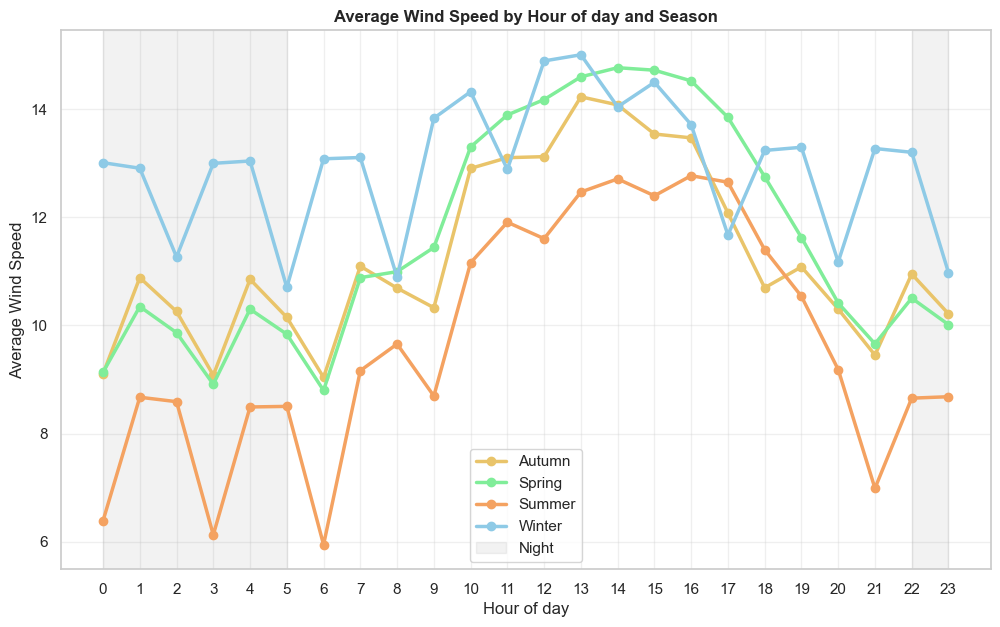

In [91]:
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df['season_name'] = df['season'].map(season_map)
df_aggr = df.groupby(['hour', 'season_name'])['hour_windspeed'].mean().unstack()
plt.figure(figsize=(12,7))
colors = {'Winter': '#8ECAE6', 'Spring': '#80ED99', 'Summer': '#F4A261', 'Autumn': '#E9C46A'}
for season in df_aggr.columns:
    plt.plot(df_aggr.index, df_aggr[season], label=season, color=colors.get(season, 'gray'), marker='o', linewidth=2.5)
plt.axvspan(22, 23, color='gray', alpha=0.1, label='Night')
plt.axvspan(0, 5, color='gray', alpha=0.1)
plt.title('Average Wind Speed by Hour of day and Season', fontweight='bold')
plt.xlabel('Hour of day')
plt.ylabel('Average Wind Speed')
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This chart illustrates the diurnal cycles and seasonal variations in wind speed.
Winter maintains the highest baseline speeds during the night and early morning.
Spring reaches the highest overall peaks during the afternoon hours 12:00–16:00.
Summer is consistently the least windy season throughout the entire day.
Wind speeds are not constant through the day, they typically increase in the morning, peak during mid-afternoon, and decrease significantly at night.

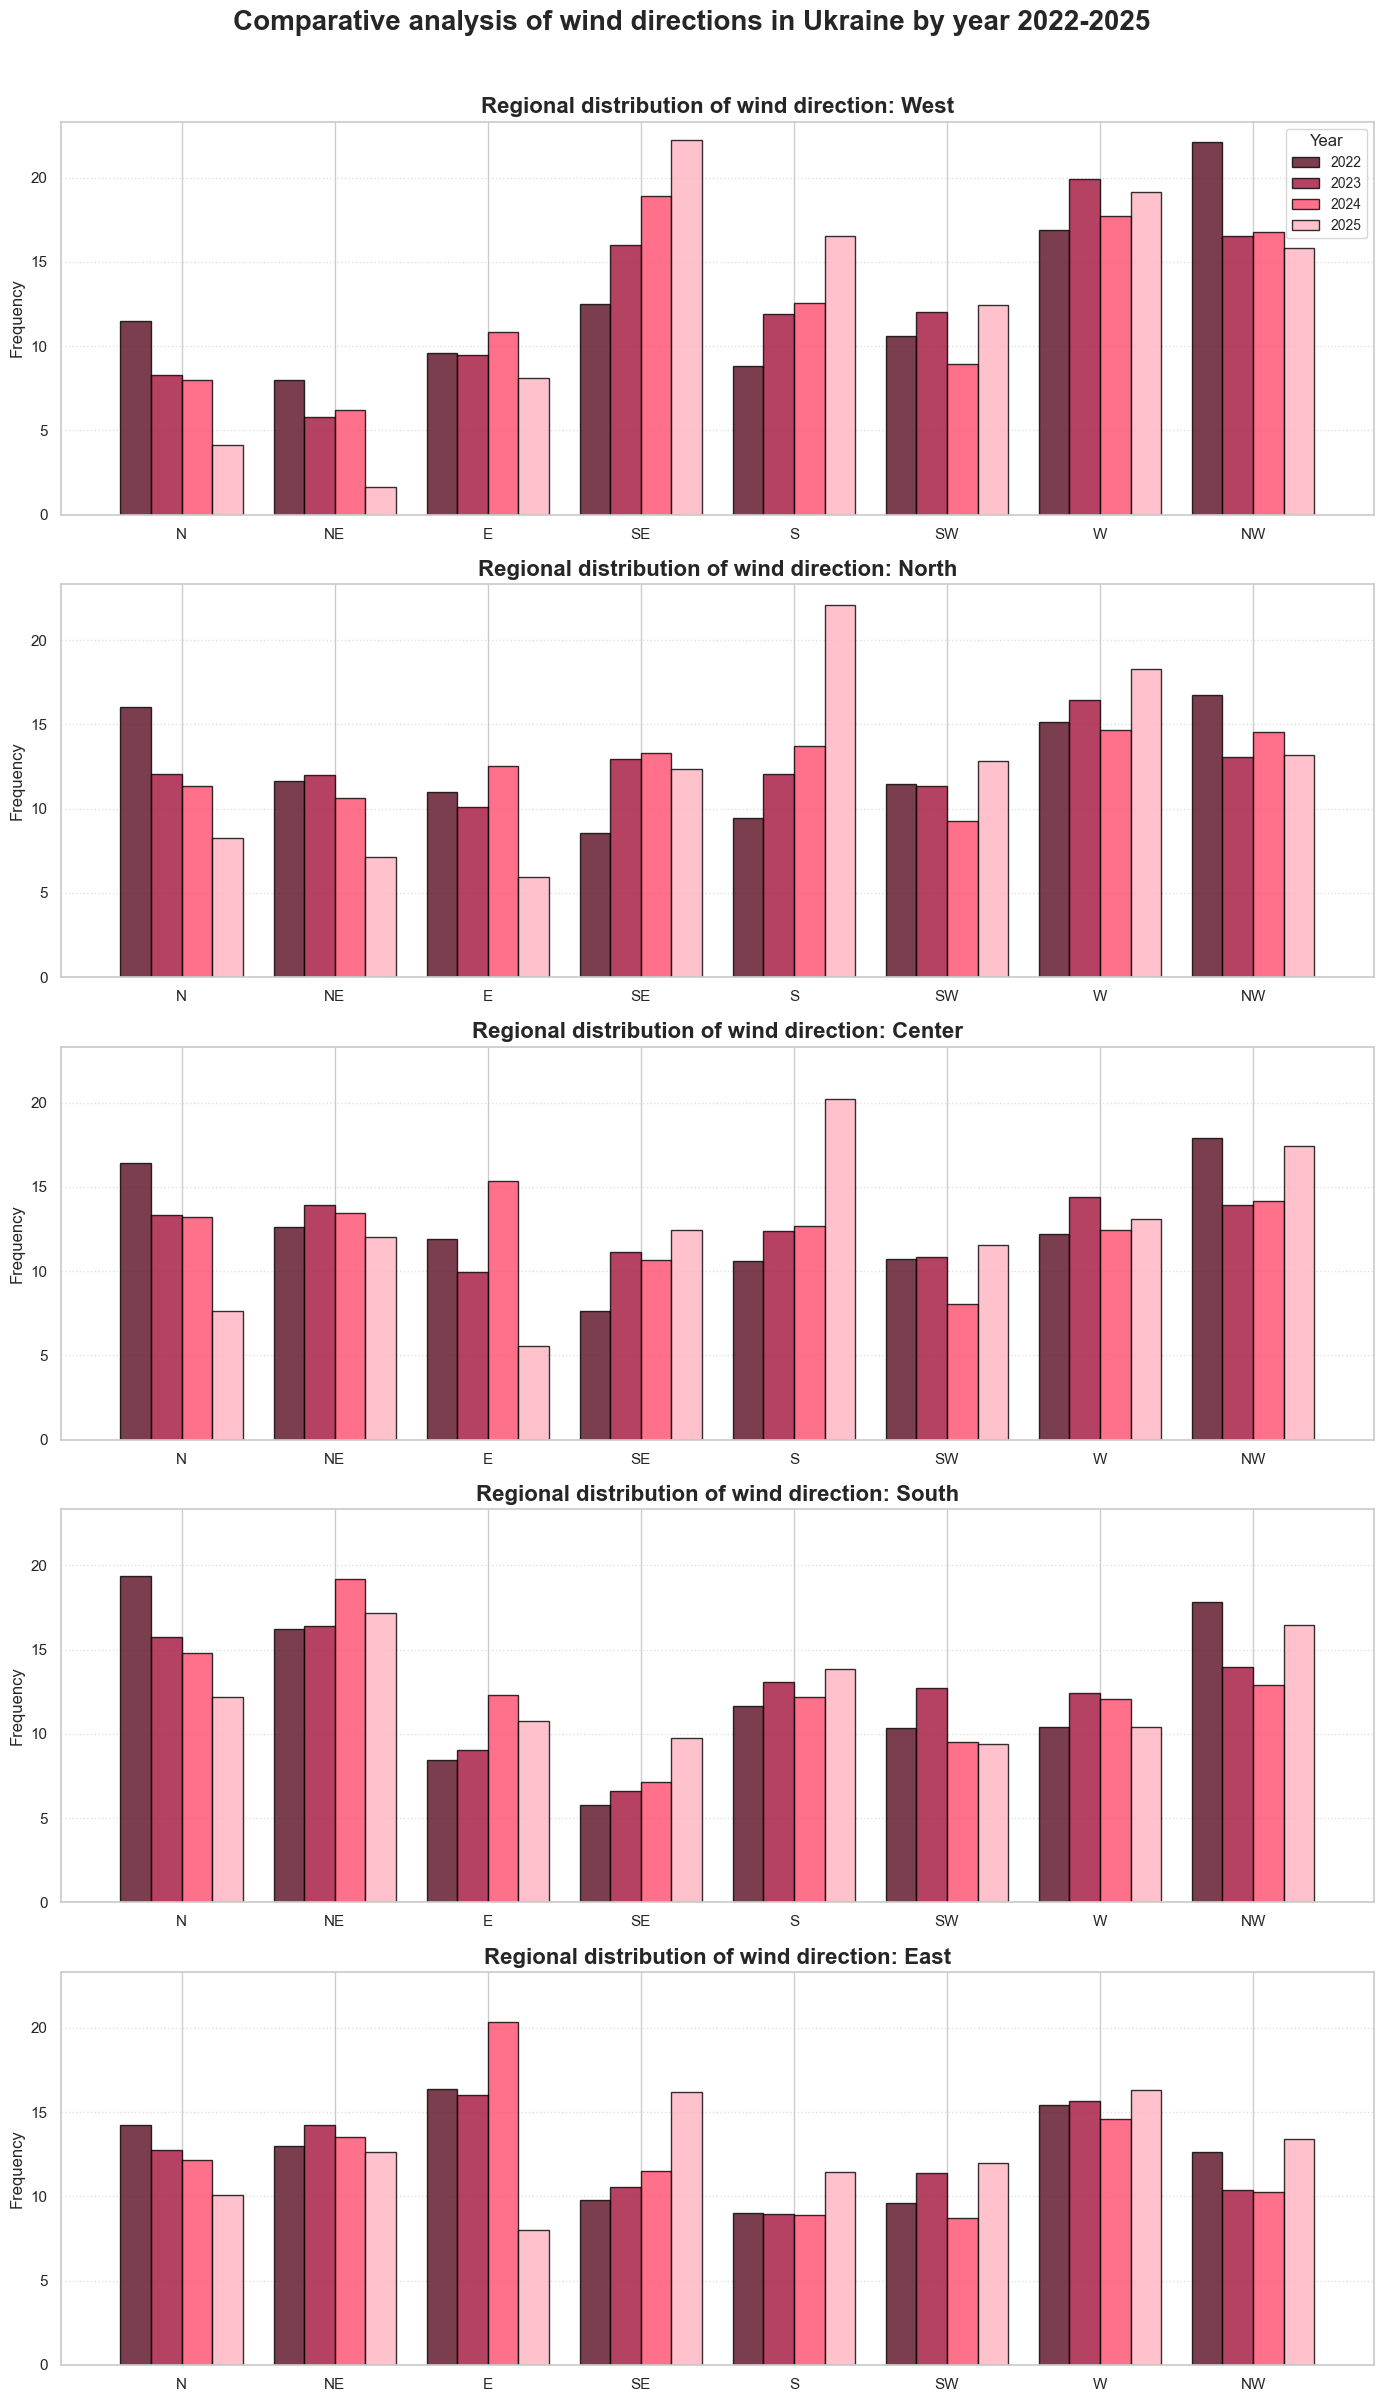

In [79]:
regions_map = {'West': ['Lviv', 'Lutsk', 'Rivne', 'Ternopil', 'Ivano-Frankivsk', 'Uzhhorod', 'Chernivtsi'],
               'North': ['Kyiv', 'Chernihiv', 'Zhytomyr', 'Sumy'],
               'Center': ['Poltava', 'Cherkasy', 'Kropyvnytskyi', 'Vinnytsia', 'Dnipro'],
               'South': ['Odesa', 'Mykolaiv', 'Kherson', 'Zaporizhzhia'],
               'East': ['Kharkiv', 'Donetsk']}
def assign_region(city):
    for reg, cities in regions_map.items():
        if city in cities: return reg
    return 'Other'

df['region'] = df['city_address'].apply(assign_region)
def get_direction(deg):
    if (deg >= 337.5) or (deg < 22.5): return 'N'
    if (deg >= 22.5) and (deg < 67.5): return 'NE'
    if (deg >= 67.5) and (deg < 112.5): return 'E'
    if (deg >= 112.5) and (deg < 157.5): return 'SE'
    if (deg >= 157.5) and (deg < 202.5): return 'S'
    if (deg >= 202.5) and (deg < 247.5): return 'SW'
    if (deg >= 247.5) and (deg < 292.5): return 'W'
    if (deg >= 292.5) and (deg < 337.5): return 'NW'
    return 'N/A'

df['wind_dir_cat'] = df['hour_winddir'].apply(get_direction)
ordered_dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
ordered_regions = ['West', 'North', 'Center', 'South', 'East']
years = sorted(df['year'].unique())
colors = ['#590d22', '#a4133c', '#ff4d6d', '#ffb3c1']
fig, axes = plt.subplots(5, 1, figsize=(14, 25), sharey=True)
plt.subplots_adjust(hspace=0.4)
width = 0.2
x = np.arange(len(ordered_dirs))
for i, region in enumerate(ordered_regions):
    ax = axes[i]
    reg_df = df[df['region'] == region]
    for j, year in enumerate(years):
        subset = reg_df[reg_df['year'] == year]
        if not subset.empty:
            counts = subset['wind_dir_cat'].value_counts(normalize=True).reindex(ordered_dirs, fill_value=0) * 100
            offset = (j - len(years)/2) * width + width/2
            ax.bar(x + offset, counts, width, label=str(year), color=colors[j], edgecolor='black', alpha=0.8)
    ax.set_title(f'Regional distribution of wind direction: {region}', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_dirs, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    if i == 0:
        ax.legend(title='Year', fontsize=10, loc='upper right')
plt.suptitle('Comparative analysis of wind directions in Ukraine by year 2022-2025', fontsize=20, fontweight='bold', y=0.99)
plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

West: This region shows the most significant shifts. There is a steady increase in South-East (SE) winds, which became dominant in 2025. Conversely, North (N) and North-East (NE) frequencies have dropped significantly.
North: 2025 saw a sharp rise in South (S) winds and a noticeable decline in North (N) winds. While East (E) winds remain minimal, West (W) winds have shown stable growth over the last three years.
Center: South (S) winds spiked to over 20% in 2025. A 2024 surge in East (E) winds was followed by a sharp drop in 2025. North-West (NW) remains one of the most stable and frequent directions.
South: The most balanced region. While North (N) and North-East (NE) are traditionally dominant, Northern winds have been declining since 2022. There is a gradual upward trend in South (S) and North-West (NW) directions.
East: After dominating in 2024, East (E) winds halved in frequency by 2025. Instead, South-East (SE) and West (W) winds saw significant growth. North-East (NE) remains the most stable direction over the period.

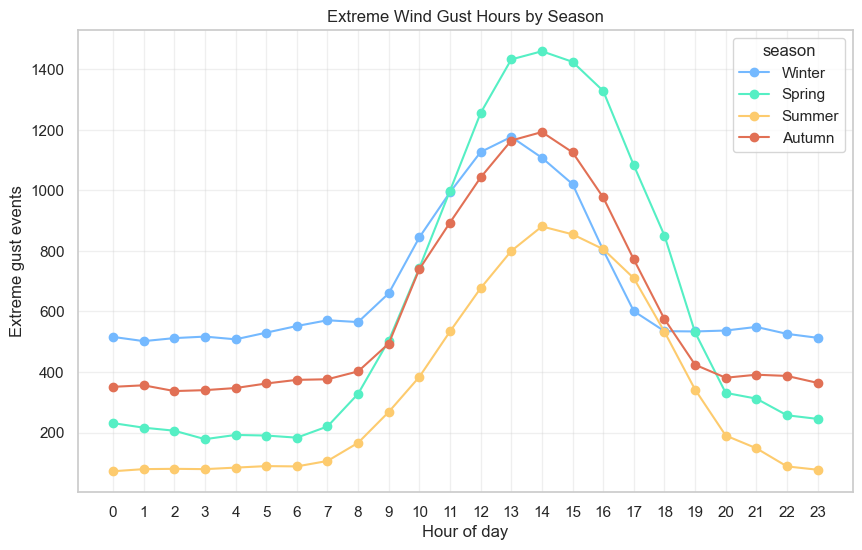

In [81]:
extreme = df[df['hour_windgust'] > 40]
pivot = extreme.pivot_table(index='hour', columns='season', aggfunc='size')
season_labels = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
pivot = pivot.rename(columns=season_labels)
colors = ['#74b9ff', '#55efc4', '#fdcb6e', '#e17055']
pivot.plot(figsize=(10,6), marker='o', color=colors)
plt.xlabel('Hour of day')
plt.ylabel('Extreme gust events')
plt.title('Extreme Wind Gust Hours by Season')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

The chart illustrates a clear diurnal cycle in extreme wind activity across all seasons.
Minimum activity occurs between 00:00 and 07:00, followed by a sharp increase after 08:00, peaking between 13:00 and 15:00.
Spring: Shows the highest overall peak due to significant thermal contrasts.
Winter and Autumn: Both share similar daytime amplitudes
Summer: Exhibits a distinct daytime peak but records the lowest overall frequency of extreme gusts.

Hypothesis 4
Significant fluctuations in atmospheric pressure during the day usually indicate unstable weather conditions. Atmospheric pressure can act as an indicator of other atmospheric processes such as cyclones, anticyclones, weather changes, wind, and precipitation. Seasonal variations in atmospheric pressure may be associated with active weather processes that could theoretically influence the duration of air raid alerts.

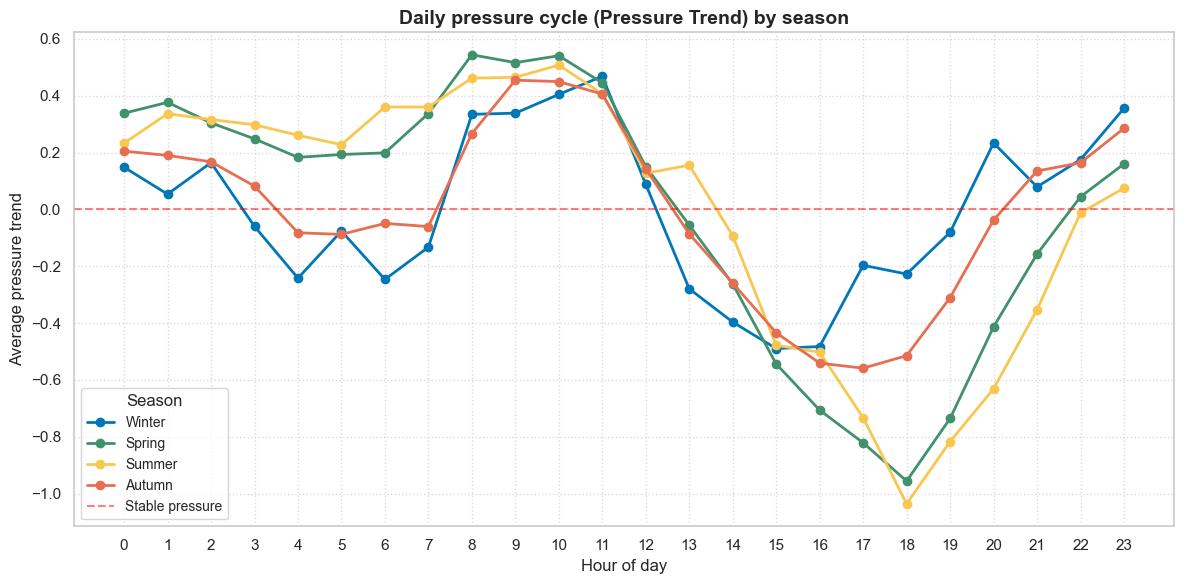

In [85]:
seasons = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
df_pressure = (df.groupby(['season', 'hour'])['pressure_trend'].mean().unstack(level=0).rename(columns=seasons))
season_colors = {'Winter': '#0077b6', 'Spring': '#40916c', 'Summer': '#f9c74f', 'Autumn': '#e76f51'}
plt.figure(figsize=(12, 6))
for season in df_pressure.columns:
    plt.plot(df_pressure.index, df_pressure[season], marker='o',
             label=season, linewidth=2, color=season_colors[season])
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Stable pressure')
plt.title('Daily pressure cycle (Pressure Trend) by season', fontsize=14, fontweight='bold')
plt.xlabel('Hour of day', fontsize=12)
plt.ylabel('Average pressure trend', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Season', fontsize=10)
plt.tight_layout()
plt.show()

The chart illustrates the dynamic variance in pressure trends across seasons, highlighting a distinct diurnal cycle.
Summer and Spring exhibit the highest amplitudes, whereas Winter shows a significantly flatter trend (lower amplitude).
00:00 - 10:00: The trend remains consistently positive during this period, with a sharp upward trajectory between 05:00 and 10:00, reaching its peak around 09:00 - 10:00.
11:00 - 18:00: A rarefaction phase occurs after 11:00, where all seasonal curves drop sharply below the zero threshold.
19:00 - 23:00: A stabilization phase where pressure trends begin returning to baseline levels.

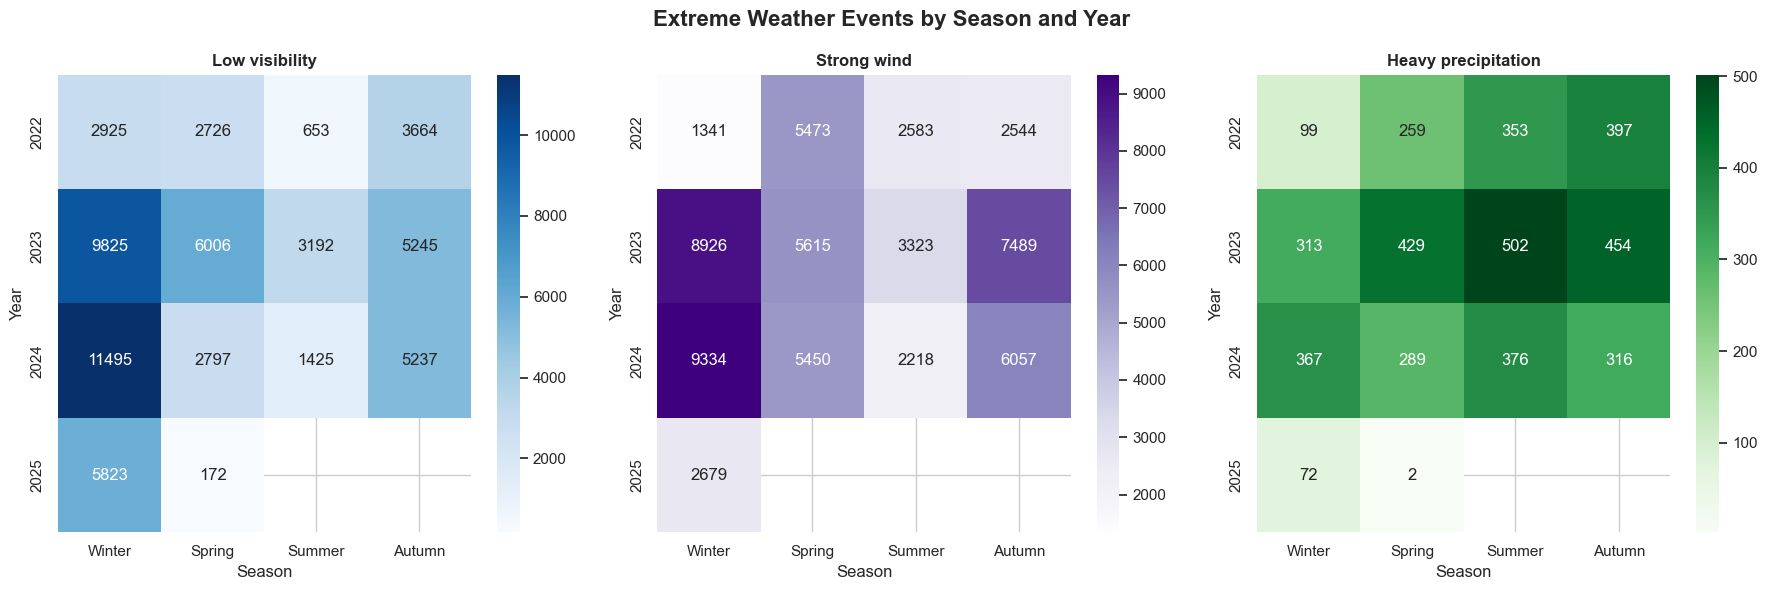

In [86]:
df['year'] = pd.to_datetime(df['day_datetime']).dt.year
conditions = {'Low visibility': df['hour_visibility'] < 5,
              'Strong wind': df['hour_windspeed'] > 20,
              'Heavy precipitation': df['hour_precip'] > 2}
cmaps = {'Low visibility': 'Blues', 'Strong wind': 'Purples', 'Heavy precipitation': 'Greens'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
season_labels = ['Winter', 'Spring', 'Summer', 'Autumn']
for ax, (title, condition) in zip(axes, conditions.items()):
    subset = df[condition]
    pivot = subset.pivot_table(index='year', columns='season', values='hour_temp', aggfunc='count')
    pivot = pivot[[1, 2, 3, 4]]
    sns.heatmap(pivot, cmap=cmaps[title], annot=True, fmt='g', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Year')
    ax.set_xticklabels(season_labels)
plt.suptitle('Extreme Weather Events by Season and Year', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Extreme Weather Trends by Season and Year (2022–2025)
These heatmaps analyze the frequency of low visibility, strong winds, and heavy precipitation, highlighting a clear escalation in extreme events.
Low Visibility: Records the highest overall frequency across all categories. Winter 2024 reached an absolute peak of 11,495 events. While Winter and Autumn consistently show the worst visibility, Summer remains the clearest season.
Strong Wind: 2023 was a standout year for wind activity, particularly in Winter 8,926 and Autumn 7,489. While the 2022 peak occurred in Spring, recent years show a shift toward Winter dominance. Spring activity remains relatively stable compared to other seasons.
Heavy Precipitation: Frequent spikes occur in Summer and Autumn, likely due to intense seasonal downpours. Following a peak in 2023, there was a noticeable decline in intensity during 2024.
Winter is the most hazardous season, showing the strongest correlation across all three types of extreme weather events.